### **Week 2: Build a Three-Layer ANN/MLP for Fashion-MNIST and CIFAR-10**

**== Write the Three-layer ANN/MLP ==**

Import Libraries and Set a Reproducible Random Seed

In [79]:
import random, time, numpy as np, torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED);
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

Load the Fashion-MNIST Dataset

In [80]:
train_data = datasets.FashionMNIST(
    root='data',
    train=True,
    download=True,
    transform=transform
)

test_data = datasets.FashionMNIST(
    root='data',
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=256, shuffle=False)

The DataLoaders and Verify the Dataset

In [81]:
train_loader = DataLoader(
    train_data,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_data,
    batch_size=256,
    shuffle=False
)

print("Training samples:", len(train_data))
print("Testing samples:", len(test_data))

images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Training samples: 60000
Testing samples: 10000
Image batch shape: torch.Size([64, 1, 28, 28])
Label batch shape: torch.Size([64])


Display Fashion-MNIST Samples

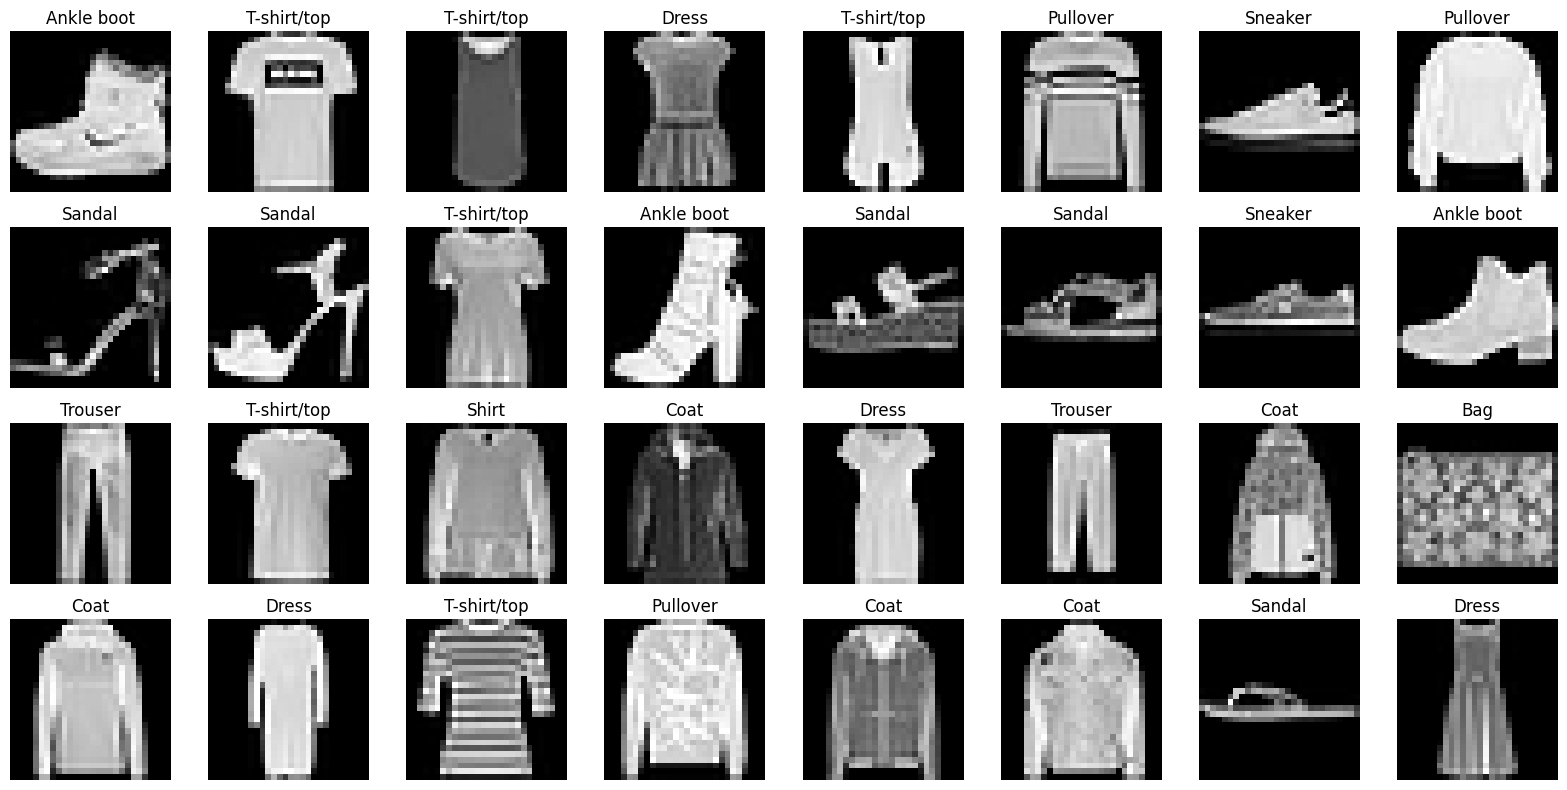

In [82]:
import matplotlib.pyplot as plt

# Ensure class_names are defined, as they are used below.
# Assuming class_names are defined from a previous cell or will be defined.
# If not, please define them first.
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

fig, axes = plt.subplots(4, 8, figsize=(16, 8)) # Display a larger grid (e.g., 4 rows, 8 columns)

for i, ax in enumerate(axes.flat):
    if i >= len(train_data): # Avoid index out of bounds if there are fewer samples than subplots
        break
    image, label = train_data[i]
    image = image.squeeze() # Remove the channel dimension for grayscale images

    ax.imshow(image, cmap="gray")
    ax.set_title(class_names[label])
    ax.axis("off") # Turn off axes for cleaner display

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

### **--RUN A--**

MLP Model


In [83]:
class FashionMLP(nn.Module):
    def __init__(self):
        super().__init__()

        #STUDENT: define three trainable Linear Layers
        self.flatten = nn.Flatten()  #Convert 28x28 image to 784 features
        self.fc1 = nn.Linear(784, 128)  #Hidden Layer 1
        self.fc2 = nn.Linear(128, 64) #Hidden Layer 2
        self.fc3 = nn.Linear(64, 10)  #Output Layer

        self.activation = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)
        x = self.activation(self.fc1(x))
        x = self.activation(self.fc2(x))
        logits = self.fc3(x)

        return logits

model = FashionMLP().to(device)
print(model)

FashionMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
  (activation): ReLU()
)


Print Parameter Count


In [84]:
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Trainable Parameters:", total_params)

Trainable Parameters: 109386


Print Tensor Shape after every stage for one batch

In [85]:
images, labels = next(iter(train_loader))

print("Input shape:", images.shape)

x = model.flatten(images)
print("After Flatten:", x.shape)

x = model.activation(model.fc1(x))
print("After Layer 1:", x.shape)

x = model.activation(model.fc2(x))
print("After Layer 2:", x.shape)

x = model.fc3(x)
print("After Layer 3:", x.shape)

Input shape: torch.Size([64, 1, 28, 28])
After Flatten: torch.Size([64, 784])
After Layer 1: torch.Size([64, 128])
After Layer 2: torch.Size([64, 64])
After Layer 3: torch.Size([64, 10])


- Layer 1 uses 784 inputs because of the converted 28*28 pixels images to 784 element vector, which came from nn.Flatten().
- Hidden layers use ReLu function is applied to inreoduce non-linearity into the model.
- Layer 3 has 10 outputs because the dataset Fashion-MNIST is a 10 class classification such as T-shirt/top, coat, pullover, etc. Each of these 10 outputs corresponds to the model's confidence for one of the classes.
- Model return logits because they represent the model's uncalibrated predictions for each class.

**== Training Loop: Forward and Backpropagation ==**

In [86]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

def train_one_epoch(model, loader):
  model.train()
  running_loss, correct, total = 0.0, 0, 0
  for images, labels in loader:
    images, labels = images.to(device), labels.to(device)

    optimizer.zero_grad()   #clear previous gradients
    logits = model(images)  #formward propogation
    loss = criterion(logits, labels)
    loss.backward()         #backward propogation
    optimizer.step()        #parameter update

    running_loss += loss.item()*labels.size(0)
    correct+= (logits.argmax(1) == labels).sum().item()
    total += labels.size(0)

  return running_loss/total,correct/total

  epoch_loss = running_loss / total
  epoch_accuracy = correct / total

  return epoch_loss, epoch_accuracy


Text/Evaluation function

In [87]:
def evaluate(model, loader):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)

            loss = criterion(logits, labels)

            running_loss += loss.item() * labels.size(0)

            predictions = logits.argmax(1)

            correct += (predictions == labels).sum().item()

            total += labels.size(0)

    loss = running_loss / total
    accuracy = correct / total

    return loss, accuracy

Start Training Time

In [88]:
start = time.time()

for epoch in range(EPOCHS):
    ...

In [89]:
EPOCHS = 10

train_losses = []
train_accuracies = []

test_losses = []
test_accuracies = []

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(model, train_loader)

    test_loss, test_acc = evaluate(model, test_loader)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.4f}")
    print(f"Test Loss : {test_loss:.4f} | Test Accuracy : {test_acc:.4f}")
    print("-"*50)

Epoch 1/10
Train Loss: 1.0047 | Train Accuracy: 0.6769
Test Loss : 0.6254 | Test Accuracy : 0.7726
--------------------------------------------------
Epoch 2/10
Train Loss: 0.5484 | Train Accuracy: 0.8037
Test Loss : 0.5306 | Test Accuracy : 0.8053
--------------------------------------------------
Epoch 3/10
Train Loss: 0.4802 | Train Accuracy: 0.8296
Test Loss : 0.5005 | Test Accuracy : 0.8203
--------------------------------------------------
Epoch 4/10
Train Loss: 0.4474 | Train Accuracy: 0.8408
Test Loss : 0.4756 | Test Accuracy : 0.8297
--------------------------------------------------
Epoch 5/10
Train Loss: 0.4261 | Train Accuracy: 0.8482
Test Loss : 0.4553 | Test Accuracy : 0.8402
--------------------------------------------------
Epoch 6/10
Train Loss: 0.4081 | Train Accuracy: 0.8552
Test Loss : 0.4469 | Test Accuracy : 0.8363
--------------------------------------------------
Epoch 7/10
Train Loss: 0.3949 | Train Accuracy: 0.8588
Test Loss : 0.4620 | Test Accuracy : 0.8277
-

End Training Time

In [90]:
end = time.time()

train_time = end-start

print(train_time)

297.5267970561981


Inference Time

In [91]:
start = time.time()

test_loss, test_acc = evaluate(model,test_loader)

end = time.time()

inference_time = end-start

print(inference_time)

3.484949827194214


Question 1:
- optimzer.zero_grad() resets the gradients from the last training iteration to prevent accumulation.
- model(images) performs the forward pass by passing the input images through the neural network to produce logits.
- loss.backward() computes the gradients of the loss with respect to all trainable parameters using backpropagation.
- optimizer_step() updates the model's weights using the computed gradients to minimize the loss.


---


Question 2
- The model's output comprises 10 logits, with each logit indicating the score for a specific clothing category. Using argmax(1) identifies the index of the highest logit for every sample, reflecting the predicted class by the model.


---


Question 3
- model.eval() sets the model to evaluation mode, ensuring that components like dropout and batch normalization function correctly during testing. torch.no_grad() turns off gradient calculation, which decreases memory consumption and accelerates evaluation since gradients are unnecessary for predictions.

**== Controlled Hyperparameter Experiment ==**

Plot Learning Curves

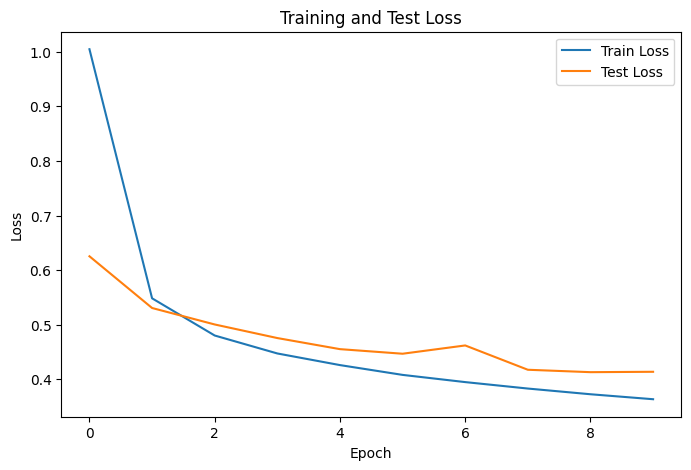

In [92]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Test Loss")
plt.legend()

plt.show()

Compute Macro F1 Score

In [93]:
from sklearn.metrics import f1_score

model.eval()

predictions = []
targets = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        logits = model(images)

        preds = logits.argmax(1).cpu().numpy()

        predictions.extend(preds)
        targets.extend(labels.numpy())

macro_f1 = f1_score(
    targets,
    predictions,
    average="macro"
)

print("Macro F1:", macro_f1)

Macro F1: 0.8461981977566779


Confusion Matrix

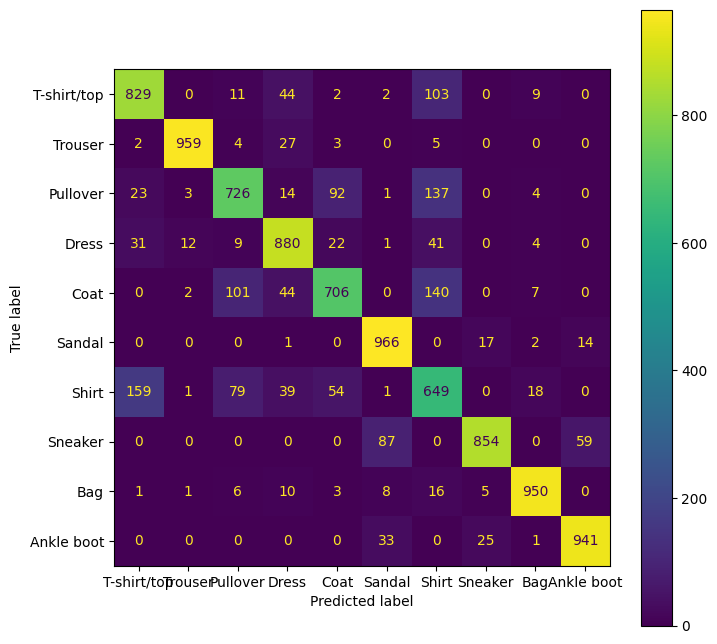

In [94]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(
    targets,
    predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8,8))

disp.plot(ax=ax)

plt.show()

Sample Predictions

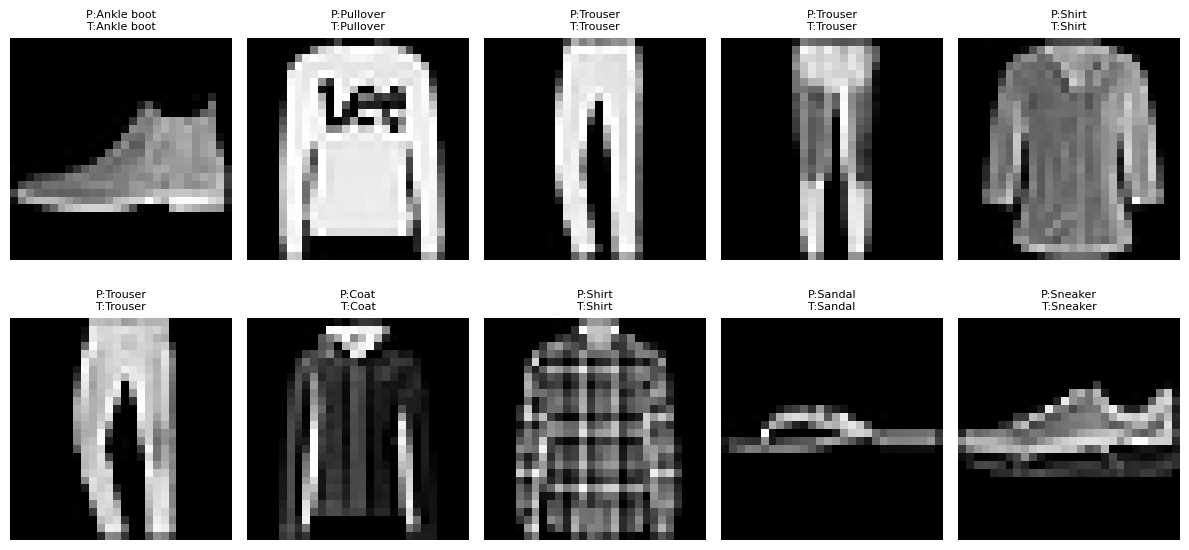

In [95]:
fig, axes = plt.subplots(2,5, figsize=(12,6))

model.eval()

images, labels = next(iter(test_loader))

images_device = images.to(device)

with torch.no_grad():

    outputs = model(images_device)

preds = outputs.argmax(1).cpu()

for i, ax in enumerate(axes.flat):

    ax.imshow(images[i].squeeze(), cmap="gray")

    ax.set_title(
        f"P:{class_names[preds[i]]}\nT:{class_names[labels[i]]}",
        fontsize=8
    )

    ax.axis("off")

plt.tight_layout()

plt.show()

### **--RUN B--**

MLP Model

In [96]:
class FashionMLP(nn.Module):
    def __init__(self):
        super().__init__()

        #STUDENT: define three trainable Linear Layers
        self.flatten = nn.Flatten()  #Convert 28x28 image to 784 features
        self.fc1 = nn.Linear(784, 128)  #Hidden Layer 1
        self.fc2 = nn.Linear(128, 64) #Hidden Layer 2
        self.fc3 = nn.Linear(64, 10)  #Output Layer

        self.activation = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)
        x = self.activation(self.fc1(x))
        x = self.activation(self.fc2(x))
        logits = self.fc3(x)

        return logits

model = FashionMLP().to(device)
print(model)

FashionMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
  (activation): ReLU()
)


Parameter Count

In [97]:
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Trainable Parameters:", total_params)

Trainable Parameters: 109386


Print Tensor Shape after every stage for one batch

In [98]:
images, labels = next(iter(train_loader))

print("Input shape:", images.shape)

x = model.flatten(images)
print("After Flatten:", x.shape)

x = model.activation(model.fc1(x))
print("After Layer 1:", x.shape)

x = model.activation(model.fc2(x))
print("After Layer 2:", x.shape)

x = model.fc3(x)
print("After Layer 3:", x.shape)

Input shape: torch.Size([64, 1, 28, 28])
After Flatten: torch.Size([64, 784])
After Layer 1: torch.Size([64, 128])
After Layer 2: torch.Size([64, 64])
After Layer 3: torch.Size([64, 10])


**== Training Loop: Forward and Backpropagation ==**

In [99]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

def train_one_epoch(model, loader):
  model.train()
  running_loss, correct, total = 0.0, 0, 0
  for images, labels in loader:
    images, labels = images.to(device), labels.to(device)

    optimizer.zero_grad()   #clear previous gradients
    logits = model(images)  #formward propogation
    loss = criterion(logits, labels)
    loss.backward()         #backward propogation
    optimizer.step()        #parameter update

    running_loss += loss.item()*labels.size(0)
    correct+= (logits.argmax(1) == labels).sum().item()
    total += labels.size(0)

  return running_loss/total,correct/total

  epoch_loss = running_loss / total
  epoch_accuracy = correct / total

  return epoch_loss, epoch_accuracy


Text/Evaluation function

In [100]:
def evaluate(model, loader):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)

            loss = criterion(logits, labels)

            running_loss += loss.item() * labels.size(0)

            predictions = logits.argmax(1)

            correct += (predictions == labels).sum().item()

            total += labels.size(0)

    loss = running_loss / total
    accuracy = correct / total

    return loss, accuracy

Start Training Time

In [101]:
start = time.time()

for epoch in range(EPOCHS):
    ...

In [78]:
EPOCHS = 10

train_losses_b = []
train_accuracies_b = []

test_losses_b = []
test_accuracies_b = []

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(model, train_loader)

    test_loss, test_acc = evaluate(model, test_loader)

    train_losses_b.append(train_loss)
    train_accuracies_b.append(train_acc)

    test_losses_b.append(test_loss)
    test_accuracies_b.append(test_acc)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.4f}")
    print(f"Test Loss : {test_loss:.4f} | Test Accuracy : {test_acc:.4f}")
    print("-"*50)

Epoch 1/10
Train Loss: 0.2834 | Train Accuracy: 0.8945
Test Loss : 0.3500 | Test Accuracy : 0.8716
--------------------------------------------------
Epoch 2/10
Train Loss: 0.2703 | Train Accuracy: 0.9006
Test Loss : 0.3488 | Test Accuracy : 0.8750
--------------------------------------------------
Epoch 3/10
Train Loss: 0.2562 | Train Accuracy: 0.9045
Test Loss : 0.3515 | Test Accuracy : 0.8702
--------------------------------------------------
Epoch 4/10
Train Loss: 0.2482 | Train Accuracy: 0.9071
Test Loss : 0.3448 | Test Accuracy : 0.8748
--------------------------------------------------
Epoch 5/10
Train Loss: 0.2382 | Train Accuracy: 0.9113
Test Loss : 0.3488 | Test Accuracy : 0.8772
--------------------------------------------------
Epoch 6/10
Train Loss: 0.2300 | Train Accuracy: 0.9142
Test Loss : 0.3299 | Test Accuracy : 0.8878
--------------------------------------------------
Epoch 7/10
Train Loss: 0.2209 | Train Accuracy: 0.9164
Test Loss : 0.3334 | Test Accuracy : 0.8852
-

End Training Time

In [137]:
end = time.time()

train_time = end-start

print(train_time)

175.49764251708984


Inference Time

In [103]:
start = time.time()

test_loss, test_acc = evaluate(model,test_loader)

end = time.time()

inference_time = end-start

print(inference_time)

4.5675084590911865


**== Controlled Hyperparameter Experiment ==**

Plot Learning Curves

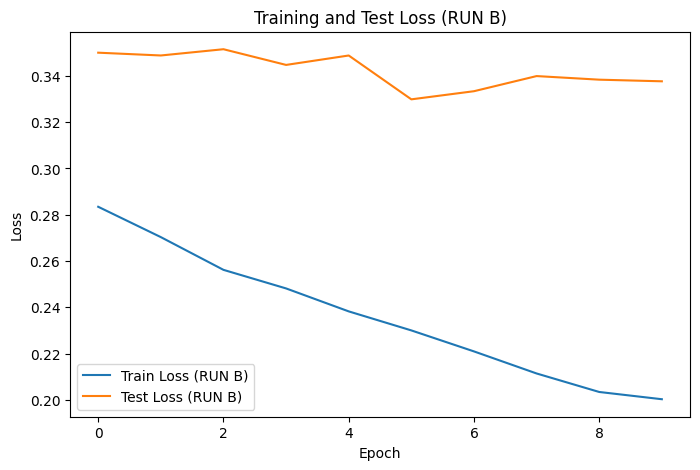

In [104]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(train_losses_b, label="Train Loss (RUN B)")
plt.plot(test_losses_b, label="Test Loss (RUN B)")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Test Loss (RUN B)")
plt.legend()

plt.show()

Compute Macro F1 Score

In [143]:
from sklearn.metrics import f1_score

model.eval()

predictions_b = []
targets_b = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        logits = model(images)

        preds = logits.argmax(1).cpu().numpy()

        predictions_b.extend(preds)
        targets_b.extend(labels.numpy())

macro_f1_b = f1_score(
    targets_b,
    predictions_b,
    average="macro"
)

print("Macro F1 (RUN B):", macro_f1_b)

Macro F1 (RUN B): 0.8720011504935435


Confusion Matrix

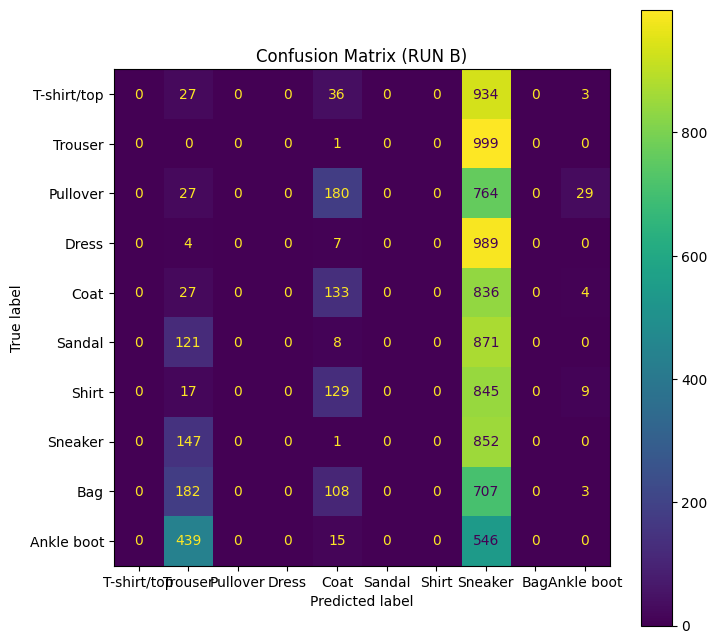

In [106]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm_b = confusion_matrix(
    targets_b,
    predictions_b
)

disp_b = ConfusionMatrixDisplay(
    confusion_matrix=cm_b,
    display_labels=class_names
)

fig_b, ax_b = plt.subplots(figsize=(8,8))

disp_b.plot(ax=ax_b)

plt.title("Confusion Matrix (RUN B)")
plt.show()

Sample Predictions

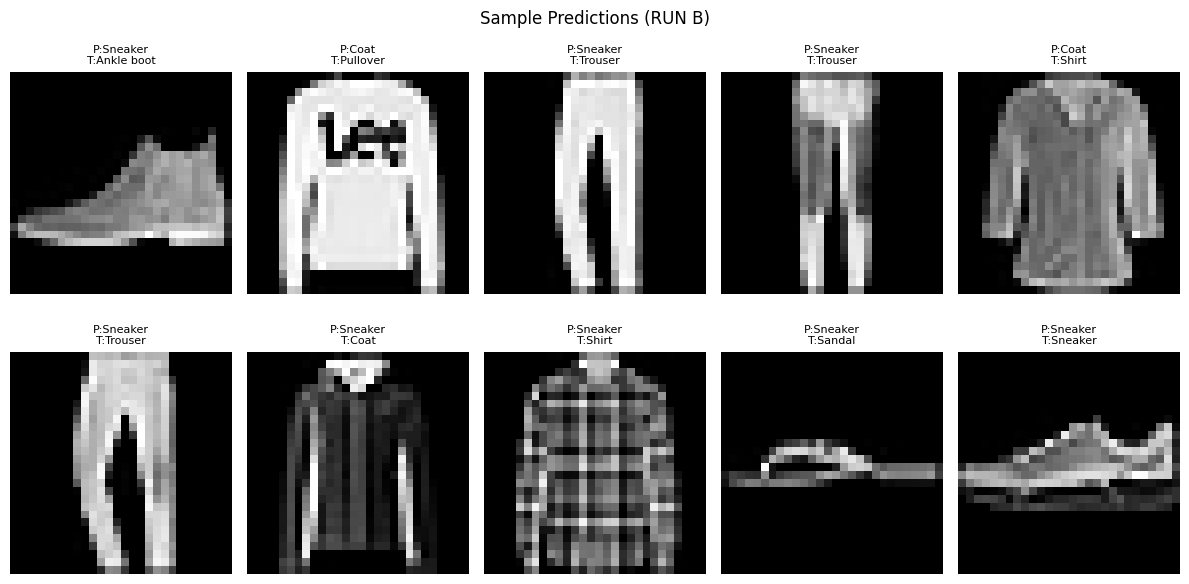

In [107]:
fig_b_sample, axes_b_sample = plt.subplots(2,5, figsize=(12,6))

model.eval()

images_b_sample, labels_b_sample = next(iter(test_loader))

images_device_b_sample = images_b_sample.to(device)

with torch.no_grad():

    outputs_b_sample = model(images_device_b_sample)

preds_b_sample = outputs_b_sample.argmax(1).cpu()

for i, ax in enumerate(axes_b_sample.flat):

    ax.imshow(images_b_sample[i].squeeze(), cmap="gray")

    ax.set_title(
        f"P:{class_names[preds_b_sample[i]]}\nT:{class_names[labels_b_sample[i]]}",
        fontsize=8
    )

    ax.axis("off")

plt.tight_layout()
plt.suptitle("Sample Predictions (RUN B)", y=1.02) # Add a main title for the figure
plt.show()

### **--RUN C--**

In [108]:
class FashionMLP(nn.Module):
    def __init__(self):
        super().__init__()

        #STUDENT: define three trainable Linear Layers
        self.flatten = nn.Flatten()  #Convert 28x28 image to 784 features
        self.fc1 = nn.Linear(784, 256)  #Hidden Layer 1
        self.fc2 = nn.Linear(256, 64) #Hidden Layer 2
        self.fc3 = nn.Linear(64, 10)  #Output Layer

        self.activation = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)
        x = self.activation(self.fc1(x))
        x = self.activation(self.fc2(x))
        logits = self.fc3(x)

        return logits

model = FashionMLP().to(device)
print(model)

FashionMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
  (activation): ReLU()
)


Print Parameter Count


In [109]:
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Trainable Parameters:", total_params)

Trainable Parameters: 218058


Print Tensor Shape after every stage for one batch

In [110]:
images, labels = next(iter(train_loader))

print("Input shape:", images.shape)

x = model.flatten(images)
print("After Flatten:", x.shape)

x = model.activation(model.fc1(x))
print("After Layer 1:", x.shape)

x = model.activation(model.fc2(x))
print("After Layer 2:", x.shape)

x = model.fc3(x)
print("After Layer 3:", x.shape)

Input shape: torch.Size([64, 1, 28, 28])
After Flatten: torch.Size([64, 784])
After Layer 1: torch.Size([64, 256])
After Layer 2: torch.Size([64, 64])
After Layer 3: torch.Size([64, 10])


**== Training Loop: Forward and Backpropagation ==**

In [111]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

def train_one_epoch(model, loader):
  model.train()
  running_loss, correct, total = 0.0, 0, 0
  for images, labels in loader:
    images, labels = images.to(device), labels.to(device)

    optimizer.zero_grad()   #clear previous gradients
    logits = model(images)  #formward propogation
    loss = criterion(logits, labels)
    loss.backward()         #backward propogation
    optimizer.step()        #parameter update

    running_loss += loss.item()*labels.size(0)
    correct+= (logits.argmax(1) == labels).sum().item()
    total += labels.size(0)

  return running_loss/total,correct/total

  epoch_loss = running_loss / total
  epoch_accuracy = correct / total

  return epoch_loss, epoch_accuracy


Text/Evaluation function

In [112]:
def evaluate(model, loader):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)

            loss = criterion(logits, labels)

            running_loss += loss.item() * labels.size(0)

            predictions = logits.argmax(1)

            correct += (predictions == labels).sum().item()

            total += labels.size(0)

    loss = running_loss / total
    accuracy = correct / total

    return loss, accuracy

Start Training Time

In [113]:
start = time.time()

for epoch in range(EPOCHS):
    ...

In [114]:
EPOCHS = 10

train_losses = []
train_accuracies = []

test_losses = []
test_accuracies = []

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(model, train_loader)

    test_loss, test_acc = evaluate(model, test_loader)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.4f}")
    print(f"Test Loss : {test_loss:.4f} | Test Accuracy : {test_acc:.4f}")
    print("-"*50)

Epoch 1/10
Train Loss: 0.5010 | Train Accuracy: 0.8186
Test Loss : 0.4332 | Test Accuracy : 0.8412
--------------------------------------------------
Epoch 2/10
Train Loss: 0.3712 | Train Accuracy: 0.8634
Test Loss : 0.3853 | Test Accuracy : 0.8624
--------------------------------------------------
Epoch 3/10
Train Loss: 0.3331 | Train Accuracy: 0.8766
Test Loss : 0.3668 | Test Accuracy : 0.8661
--------------------------------------------------
Epoch 4/10
Train Loss: 0.3094 | Train Accuracy: 0.8840
Test Loss : 0.3507 | Test Accuracy : 0.8740
--------------------------------------------------
Epoch 5/10
Train Loss: 0.2861 | Train Accuracy: 0.8938
Test Loss : 0.3661 | Test Accuracy : 0.8717
--------------------------------------------------
Epoch 6/10
Train Loss: 0.2735 | Train Accuracy: 0.8992
Test Loss : 0.3478 | Test Accuracy : 0.8744
--------------------------------------------------
Epoch 7/10
Train Loss: 0.2602 | Train Accuracy: 0.9021
Test Loss : 0.3538 | Test Accuracy : 0.8769
-

End Training Time

In [115]:
end = time.time()

train_time = end-start

print(train_time)

398.9998564720154


Inference Time

In [116]:
start = time.time()

test_loss, test_acc = evaluate(model,test_loader)

end = time.time()

inference_time = end-start

print(inference_time)

2.9454309940338135


**== Controlled Hyperparameter Experiment ==**

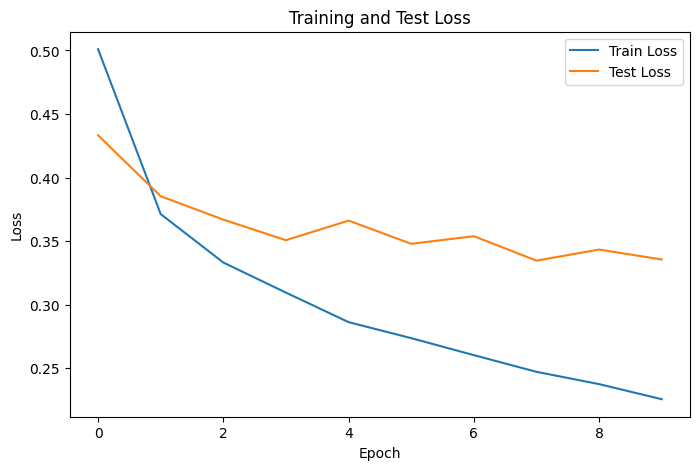

In [117]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Test Loss")
plt.legend()

plt.show()

Compute Macro F1 Score

In [118]:
from sklearn.metrics import f1_score

model.eval()

predictions = []
targets = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        logits = model(images)

        preds = logits.argmax(1).cpu().numpy()

        predictions.extend(preds)
        targets.extend(labels.numpy())

macro_f1 = f1_score(
    targets,
    predictions,
    average="macro"
)

print("Macro F1:", macro_f1)

Macro F1: 0.8867966734661993


Confusion Matrix

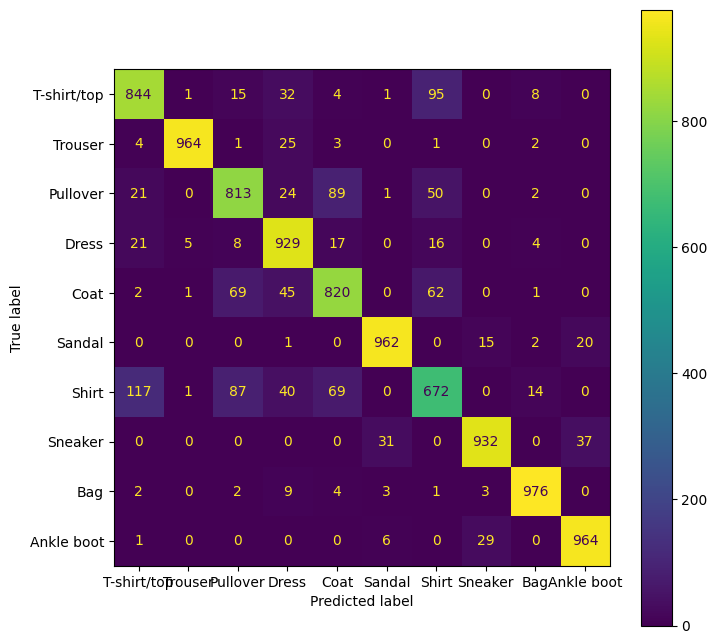

In [119]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(
    targets,
    predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8,8))

disp.plot(ax=ax)

plt.show()

Sample Predictions

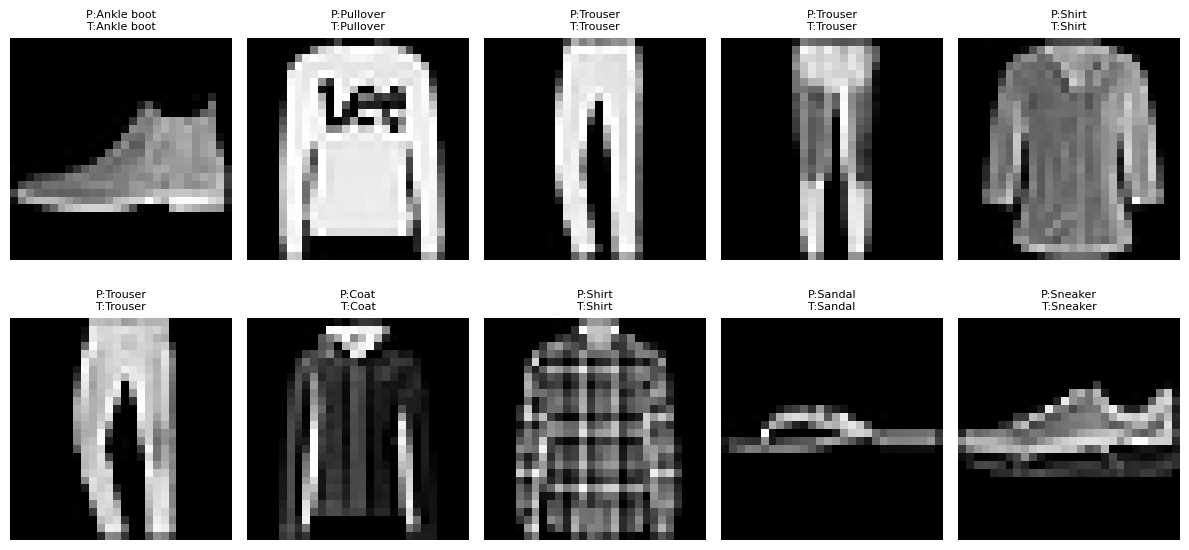

In [120]:
fig, axes = plt.subplots(2,5, figsize=(12,6))

model.eval()

images, labels = next(iter(test_loader))

images_device = images.to(device)

with torch.no_grad():

    outputs = model(images_device)

preds = outputs.argmax(1).cpu()

for i, ax in enumerate(axes.flat):

    ax.imshow(images[i].squeeze(), cmap="gray")

    ax.set_title(
        f"P:{class_names[preds[i]]}\nT:{class_names[labels[i]]}",
        fontsize=8
    )

    ax.axis("off")

plt.tight_layout()

plt.show()

### **--RUN D--**

MLP Model


In [122]:
class FashionMLP(nn.Module):
    def __init__(self):
        super().__init__()

        #STUDENT: define three trainable Linear Layers
        self.flatten = nn.Flatten()  #Convert 28x28 image to 784 features
        self.fc1 = nn.Linear(784, 128)  #Hidden Layer 1
        self.fc2 = nn.Linear(128, 64) #Hidden Layer 2
        self.fc3 = nn.Linear(64, 10)  #Output Layer

        self.activation = nn.Tanh()

    def forward(self, x):
        x = self.flatten(x)
        x = self.activation(self.fc1(x))
        x = self.activation(self.fc2(x))
        logits = self.fc3(x)

        return logits

model = FashionMLP().to(device)
print(model)

FashionMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
  (activation): Tanh()
)


Print Parameter Count


In [123]:
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Trainable Parameters:", total_params)

Trainable Parameters: 109386


Print Tensor Shape after every stage for one batch

In [124]:
images, labels = next(iter(train_loader))

print("Input shape:", images.shape)

x = model.flatten(images)
print("After Flatten:", x.shape)

x = model.activation(model.fc1(x))
print("After Layer 1:", x.shape)

x = model.activation(model.fc2(x))
print("After Layer 2:", x.shape)

x = model.fc3(x)
print("After Layer 3:", x.shape)

Input shape: torch.Size([64, 1, 28, 28])
After Flatten: torch.Size([64, 784])
After Layer 1: torch.Size([64, 128])
After Layer 2: torch.Size([64, 64])
After Layer 3: torch.Size([64, 10])


**== Training Loop: Forward and Backpropagation ==**

In [125]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

def train_one_epoch(model, loader):
  model.train()
  running_loss, correct, total = 0.0, 0, 0
  for images, labels in loader:
    images, labels = images.to(device), labels.to(device)

    optimizer.zero_grad()   #clear previous gradients
    logits = model(images)  #formward propogation
    loss = criterion(logits, labels)
    loss.backward()         #backward propogation
    optimizer.step()        #parameter update

    running_loss += loss.item()*labels.size(0)
    correct+= (logits.argmax(1) == labels).sum().item()
    total += labels.size(0)

  return running_loss/total,correct/total

  epoch_loss = running_loss / total
  epoch_accuracy = correct / total

  return epoch_loss, epoch_accuracy


Text/Evaluation function

In [126]:
def evaluate(model, loader):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)

            loss = criterion(logits, labels)

            running_loss += loss.item() * labels.size(0)

            predictions = logits.argmax(1)

            correct += (predictions == labels).sum().item()

            total += labels.size(0)

    loss = running_loss / total
    accuracy = correct / total

    return loss, accuracy

Start Training Time

In [127]:
start = time.time()

for epoch in range(EPOCHS):
    ...

In [128]:
EPOCHS = 10

train_losses = []
train_accuracies = []

test_losses = []
test_accuracies = []

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(model, train_loader)

    test_loss, test_acc = evaluate(model, test_loader)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.4f}")
    print(f"Test Loss : {test_loss:.4f} | Test Accuracy : {test_acc:.4f}")
    print("-"*50)

Epoch 1/10
Train Loss: 0.5095 | Train Accuracy: 0.8212
Test Loss : 0.4396 | Test Accuracy : 0.8399
--------------------------------------------------
Epoch 2/10
Train Loss: 0.3772 | Train Accuracy: 0.8643
Test Loss : 0.4074 | Test Accuracy : 0.8540
--------------------------------------------------
Epoch 3/10
Train Loss: 0.3493 | Train Accuracy: 0.8728
Test Loss : 0.3795 | Test Accuracy : 0.8640
--------------------------------------------------
Epoch 4/10
Train Loss: 0.3256 | Train Accuracy: 0.8822
Test Loss : 0.3897 | Test Accuracy : 0.8588
--------------------------------------------------
Epoch 5/10
Train Loss: 0.3143 | Train Accuracy: 0.8841
Test Loss : 0.3785 | Test Accuracy : 0.8648
--------------------------------------------------
Epoch 6/10
Train Loss: 0.2967 | Train Accuracy: 0.8909
Test Loss : 0.3560 | Test Accuracy : 0.8717
--------------------------------------------------
Epoch 7/10
Train Loss: 0.2877 | Train Accuracy: 0.8943
Test Loss : 0.3704 | Test Accuracy : 0.8651
-

End Training Time

In [129]:
end = time.time()

train_time = end-start

print(train_time)

299.08713936805725


Inference Time

In [130]:
start = time.time()

test_loss, test_acc = evaluate(model,test_loader)

end = time.time()

inference_time = end-start

print(inference_time)

2.353909492492676


**== Controlled Hyperparameter Experiment ==**

Plot Learning Curves

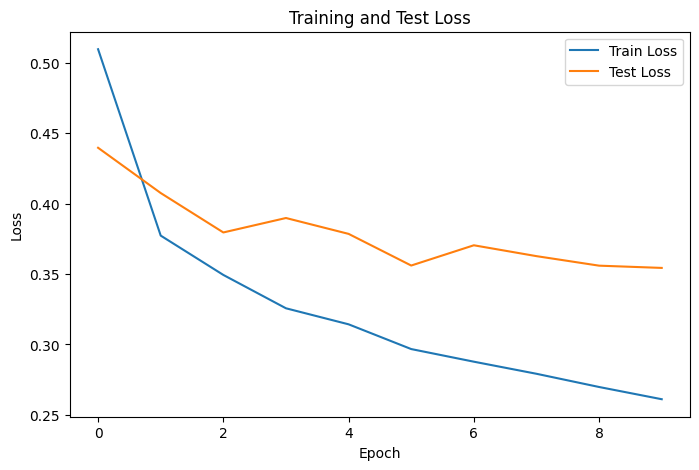

In [131]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Test Loss")
plt.legend()

plt.show()

Compute Macro F1 Score

In [132]:
from sklearn.metrics import f1_score

model.eval()

predictions = []
targets = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        logits = model(images)

        preds = logits.argmax(1).cpu().numpy()

        predictions.extend(preds)
        targets.extend(labels.numpy())

macro_f1 = f1_score(
    targets,
    predictions,
    average="macro"
)

print("Macro F1:", macro_f1)

Macro F1: 0.8720011504935435


Confusion Matrix

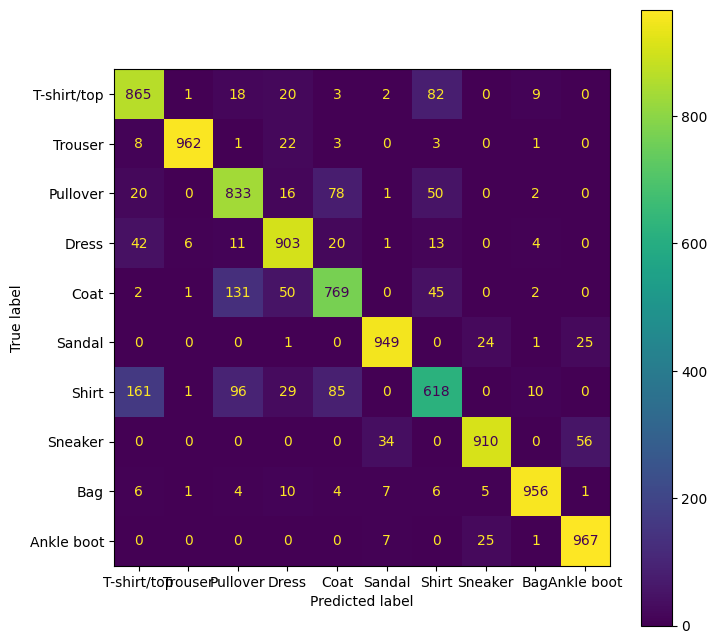

In [133]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(
    targets,
    predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8,8))

disp.plot(ax=ax)

plt.show()

Sample Predictions

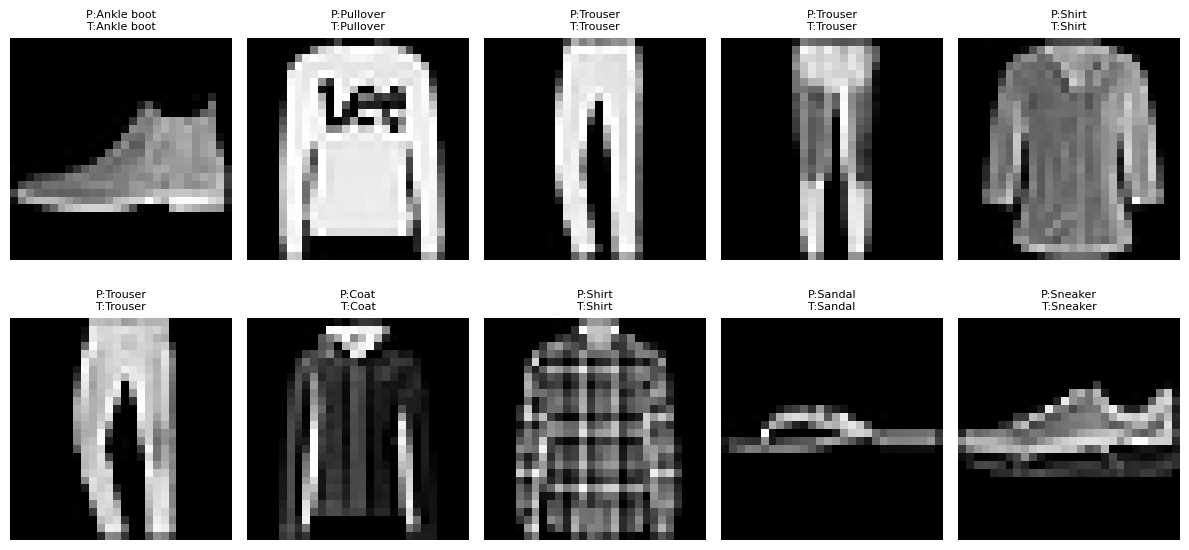

In [134]:
fig, axes = plt.subplots(2,5, figsize=(12,6))

model.eval()

images, labels = next(iter(test_loader))

images_device = images.to(device)

with torch.no_grad():

    outputs = model(images_device)

preds = outputs.argmax(1).cpu()

for i, ax in enumerate(axes.flat):

    ax.imshow(images[i].squeeze(), cmap="gray")

    ax.set_title(
        f"P:{class_names[preds[i]]}\nT:{class_names[labels[i]]}",
        fontsize=8
    )

    ax.axis("off")

plt.tight_layout()

plt.show()

### **Comparison Table of the 4 RUNS**

In [144]:
results_a = {
    "params": 109386,
    "train_losses": [0.3635],
    "test_losses": [0.4138],
    "test_accs": [0.8460],
    "macro_f1": 0.8461981977566779,
    "train_time": 297.5267970561981,
    "inference_time": 3.484949827194214
}

results_b = {
    "params": 109386,
    "train_losses": [0.2003],
    "test_losses": [0.3377],
    "test_accs": [0.8844],
    "macro_f1": 0.8720011504935435,
    "train_time": 175.49764251708984,
    "inference_time": 4.5675084590911865
}

results_c = {
    "params": 218058,
    "train_losses": [0.2255],
    "test_losses": [0.3355],
    "test_accs": [0.8876],
    "macro_f1": 0.8867966734661993,
    "train_time": 398.9998564720154,
    "inference_time": 2.9454309940338135
}

results_d = {
    "params": 109386,
    "train_losses": [0.2611],
    "test_losses": [0.3543],
    "test_accs": [0.8732],
    "macro_f1": 0.8720011504935435,
    "train_time": 299.08713936805725,
    "inference_time": 2.353909492492676
}

In [145]:
all_results = {"A": results_a, "B": results_b, "C": results_c, "D": results_d}
print(f"\n{'Run':<5}{'Params':<10}{'TrainLoss':<12}{'TestLoss':<11}"
      f"{'TestAcc':<10}{'MacroF1':<10}{'TrainTime':<11}{'InfTime':<10}")
for name, r in all_results.items():
    print(f"{name:<5}{r['params']:<10}{r['train_losses'][-1]:<12.4f}"
          f"{r['test_losses'][-1]:<11.4f}{r['test_accs'][-1]:<10.4f}"
          f"{r['macro_f1']:<10.4f}{r['train_time']:<11.2f}{r['inference_time']:<10.4f}")



Run  Params    TrainLoss   TestLoss   TestAcc   MacroF1   TrainTime  InfTime   
A    109386    0.3635      0.4138     0.8460    0.8462    297.53     3.4849    
B    109386    0.2003      0.3377     0.8844    0.8720    175.50     4.5675    
C    218058    0.2255      0.3355     0.8876    0.8868    399.00     2.9454    
D    109386    0.2611      0.3543     0.8732    0.8720    299.09     2.3539    
